## DATA LOADING AND INFO

In [1]:
#importing initial libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset

df = pd.read_csv("all_subjects_2020_final.csv")

In [3]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45772 entries, 0 to 45771
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   post_id             45772 non-null  object 
 1   subject             45772 non-null  object 
 2   date                45772 non-null  object 
 3   title               2392 non-null   object 
 4   text                45772 non-null  object 
 5   info                45772 non-null  object 
 6   clean_text          45098 non-null  object 
 7   depression_sim      45772 non-null  float64
 8   suicide_sim         45772 non-null  float64
 9   neutral_sim         45772 non-null  float64
 10  raw_severity_score  45772 non-null  float64
 11  severity_score      45772 non-null  float64
 12  severity            45771 non-null  float64
dtypes: float64(6), object(7)
memory usage: 4.5+ MB


In [4]:
# first five rows of dataset
df.head()

,post_id,subject,date,title,text,info,clean_text,depression_sim,suicide_sim,neutral_sim,raw_severity_score,severity_score,severity
0,subject8361_1,subject8361,2016-08-17 09:07:40,Research as an Undergrad,hey I'm an incoming freshman interested in doi...,Reddit post,hey i m an incoming freshman interested in doi...,0.059428,0.016668,0.065541,0.027689,0.184673,0.0
1,subject8361_2,subject8361,2016-09-02 19:57:13,CS class waitlist?,I'm currently 8th on the waitlist for an 86 pe...,Reddit post,i m currently th on the waitlist for an person...,0.070747,0.136558,0.116487,0.081638,0.273929,0.0
2,subject8361_3,subject8361,2016-09-08 06:53:54,NaN,go for it. If you really want to go to Columbi...,Reddit post,go for it if you really want to go to columbia...,0.098538,0.076042,0.043917,0.074169,0.261572,0.0
3,subject8361_4,subject8361,2016-11-02 06:20:59,NaN,by dedicating my life and soul to school for f...,Reddit post,by dedicating my life and soul to school for f...,0.319611,0.391793,0.119267,0.308205,0.648768,0.0
4,subject8361_5,subject8361,2016-11-05 23:32:59,NaN,who says i'm a dude... i'm definitely a girl,Reddit post,who says i m a dude i m definitely a girl,0.167680,0.138917,0.129830,0.124985,0.345643,0.0


In [5]:
print(df.shape)

(45772, 13)


In [6]:
# duplicate rows
df.duplicated().sum()

np.int64(0)

In [7]:
# missing values

df.isnull().sum()

,0
post_id,0
subject,0
date,0
title,43380
text,0
info,0
clean_text,674
depression_sim,0
suicide_sim,0
neutral_sim,0


In [8]:
df = df.dropna(subset=["clean_text"])
df = df[df["clean_text"].str.upper() != "NAN"]

In [9]:
df["severity"].value_counts()

,count
severity,
0.0,45076
1.0,14
2.0,8


## PREPROCESSING AND CLEANING

In [10]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.4 MB/s eta 0:00:00


In [11]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["clean_text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

In [12]:
depression_words = [
    "depressed","hopeless","worthless","empty",
    "cry","lonely","alone","sad","fatigue",
    "insomnia","anxiety","guilty","failure",
    "tired","helpless"
]

def depression_keyword_score(text):

    text = str(text).lower()

    return sum(word in text for word in depression_words)

df["depression_keyword"] = df["clean_text"].apply(depression_keyword_score)

In [13]:
suicide_words = [
    "kill myself",
    "suicide",
    "want to die",
    "end my life",
    "cut myself",
    "self harm",
    "overdose",
    "hang myself",
    "jump off",
    "die"
]

def suicide_keyword_score(text):

    text = str(text).lower()

    return sum(word in text for word in suicide_words)

df["suicide_keyword"] = df["clean_text"].apply(suicide_keyword_score)

In [14]:
df["raw_score"] = (

      0.35 * df["depression_sim"]

    + 0.35 * df["suicide_sim"]

    + 0.15 * df["depression_keyword"]

    + 0.10 * df["suicide_keyword"]

    - 0.15 * df["neutral_sim"]

    - 0.10 * df["sentiment"]

)

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["severity_score"] = scaler.fit_transform(
    df[["raw_score"]]
)

In [16]:
#dividing the severity score in two quantiles
low = df["severity_score"].quantile(0.33)

high = df["severity_score"].quantile(0.66)

def assign_severity(score):

    if score <= low:
        return 0

    elif score <= high:
        return 1

    else:
        return 2

df["severity"] = df["severity_score"].apply(assign_severity)

In [17]:
df['severity'].value_counts()

,count
severity,
2,15333
0,14883
1,14882


In [18]:
print(df[
[
"severity_score",
"sentiment",
"depression_keyword",
"suicide_keyword",
]
].head())

   severity_score  sentiment  depression_keyword  suicide_keyword
0        0.091839     0.4019                   0                0
1        0.139940     0.1513                   0                0
2        0.080337     0.9305                   0                0
3        0.285095     0.0000                   0                0
4        0.145780     0.4019                   0                0


In [19]:
from sklearn.preprocessing import MinMaxScaler

features = [
    "severity_score",
    "sentiment",
    "depression_keyword",
    "suicide_keyword"
]

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

In [20]:
df[features].head(20)

,severity_score,sentiment,depression_keyword,suicide_keyword
0,0.091839,0.700905,0.0,0.0
1,0.139940,0.575586,0.0,0.0
2,0.080337,0.965245,0.0,0.0
3,0.285095,0.499925,0.0,0.0
4,0.145780,0.700905,0.0,0.0
5,0.157404,0.499925,0.0,0.0
6,0.116269,0.998250,0.0,0.0
7,0.153331,0.538531,0.0,0.0
8,0.115302,0.499925,0.0,0.0
9,0.162839,0.499925,0.0,0.0


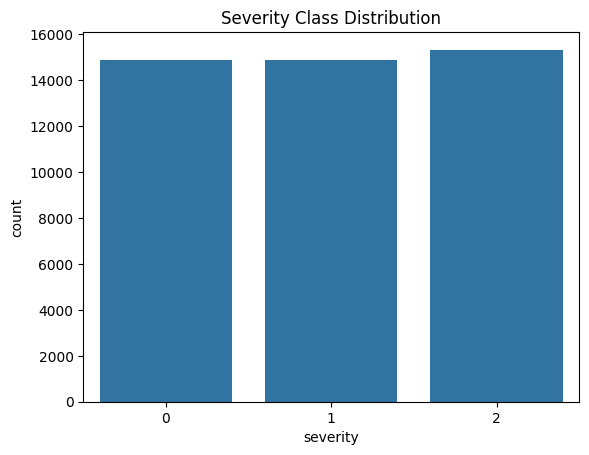

In [21]:
#severity class

sns.countplot(x='severity',data=df)

plt.title("Severity Class Distribution")
plt.show()

Text(0.5, 1.0, 'Distribution of Reddit Post Length')

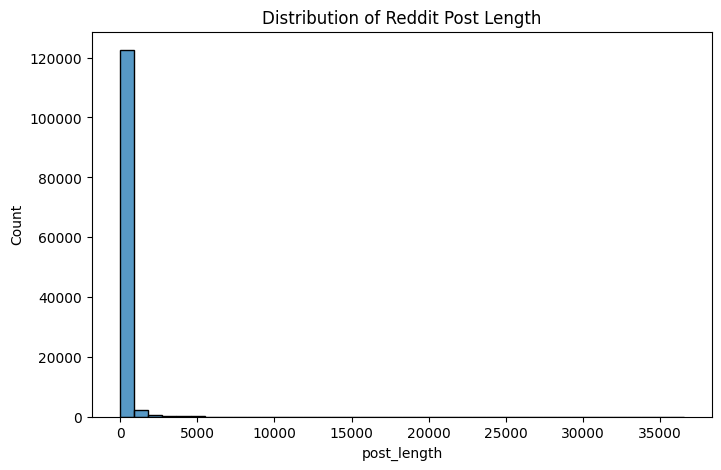

In [ ]:
# post lenght distribution

df["post_length"]=df["clean_text"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["post_length"],bins=40)

plt.title("Distribution of Reddit Post Length")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

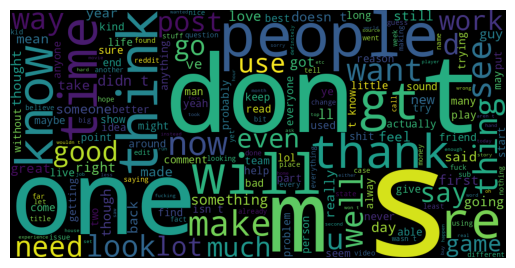

In [ ]:
#word cloud

from wordcloud import WordCloud

text=" ".join(df["clean_text"])

wordcloud=WordCloud(width=1000,height=500).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

In [ ]:
# most common words

from collections import Counter

words=" ".join(df["clean_text"]).split()

Counter(words).most_common(20)

[('the', 150130),
 ('i', 108692),
 ('to', 96785),
 ('a', 90662),
 ('and', 84828),
 ('of', 66670),
 ('it', 63385),
 ('that', 52867),
 ('you', 52637),
 ('in', 50724),
 ('is', 48747),
 ('s', 41892),
 ('for', 37201),
 ('t', 31527),
 ('this', 30551),
 ('on', 27296),
 ('but', 25445),
 ('with', 24678),
 ('my', 23553),
 ('was', 23525)]

## INTENSIVE CLEANING

In [22]:
#lower case
df["clean_text"]=df["clean_text"].str.lower()

In [23]:
# remove urls
import re

def remove_urls(text):
    return re.sub(r"http\S+","",text)

df["clean_text"]=df["clean_text"].apply(remove_urls)

In [24]:
# remove punctuation
import string

def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

df["clean_text"]=df["clean_text"].apply(remove_punctuation)

In [25]:
# remove numbers
def remove_numbers(text):
    return re.sub(r'\d+',"",text)

df["clean_text"]=df["clean_text"].apply(remove_numbers)

In [26]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [27]:
# remove stopwords

from nltk.corpus import stopwords

stop_words=set(stopwords.words("english"))

df["clean_text"]=df["clean_text"].apply(
    lambda x:" ".join([w for w in x.split() if w not in stop_words])
)

In [28]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [29]:
# lemmet

from nltk.stem import WordNetLemmatizer

lemmatizer=WordNetLemmatizer()

df["clean_text"]=df["clean_text"].apply(
lambda x:" ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

## LOADING OUR HUGGING FACE CREDENTIALS TO LOAD MENTAL BERT MODEL FOR BUILDING MODEL LATER

In [ ]:
from huggingface_hub import login

login("ENTER YOUR API TOKEN")

In [ ]:
# tokenize
from transformers import AutoTokenizer

tokenizer=AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased")

## TEMPORAL FEATURE ENGINEERING AND TRAJECTORY CONSTRUCTION



In [32]:
# create user ids

df["user_id"] = (
    df["post_id"]
    .astype(str)
    .str.split("_")
    .str[0]
)

In [33]:
df.head()

,post_id,subject,date,title,text,info,clean_text,depression_sim,suicide_sim,neutral_sim,raw_severity_score,severity_score,severity,sentiment,depression_keyword,suicide_keyword,raw_score,user_id
0,subject8361_1,subject8361,2016-08-17 09:07:40,Research as an Undergrad,hey I'm an incoming freshman interested in doi...,Reddit post,hey incoming freshman interested research poin...,0.059428,0.016668,0.065541,0.027689,0.091839,0,0.700905,0.0,0.0,-0.023388,subject8361
1,subject8361_2,subject8361,2016-09-02 19:57:13,CS class waitlist?,I'm currently 8th on the waitlist for an 86 pe...,Reddit post,currently th waitlist person c class really wa...,0.070747,0.136558,0.116487,0.081638,0.139940,1,0.575586,0.0,0.0,0.039954,subject8361
2,subject8361_3,subject8361,2016-09-08 06:53:54,NaN,go for it. If you really want to go to Columbi...,Reddit post,go really want go columbia ed way go get likel...,0.098538,0.076042,0.043917,0.074169,0.080337,0,0.965245,0.0,0.0,-0.038535,subject8361
3,subject8361_4,subject8361,2016-11-02 06:20:59,NaN,by dedicating my life and soul to school for f...,Reddit post,dedicating life soul school four year,0.319611,0.391793,0.119267,0.308205,0.285095,2,0.499925,0.0,0.0,0.231101,subject8361
4,subject8361_5,subject8361,2016-11-05 23:32:59,NaN,who says i'm a dude... i'm definitely a girl,Reddit post,say dude definitely girl,0.167680,0.138917,0.129830,0.124985,0.145780,1,0.700905,0.0,0.0,0.047644,subject8361


In [34]:
# user timeline construction

df = df.sort_values(
    ["user_id", "date"]
).reset_index(drop=True)

In [35]:
# creating rolling severity

window_size = 5

df["rolling_severity"] = (

    df.groupby("user_id")["severity_score"]

      .transform(
          lambda x:
          x.rolling(
              window=window_size,
              min_periods=1
          ).mean()
      )

)

In [36]:
# computing evs

df["evs"] = (

    df.groupby("user_id")["rolling_severity"]

      .diff()

      .fillna(0)

)

In [37]:
# inspecting evs

print(df["evs"].describe())

print("Negative :", (df["evs"]<0).sum())

print("Zero :", (df["evs"]==0).sum())

print("Positive :", (df["evs"]>0).sum())

count    45098.000000
mean         0.000010
std          0.015936
min         -0.164983
25%         -0.009383
50%          0.000000
75%          0.009480
max          0.159477
Name: evs, dtype: float64
Negative : 22303
Zero : 276
Positive : 22519


In [38]:
print(df["evs"].describe())

print("Negative EVS :", (df["evs"] < 0).sum())
print("Zero EVS :", (df["evs"] == 0).sum())
print("Positive EVS :", (df["evs"] > 0).sum())

count    45098.000000
mean         0.000010
std          0.015936
min         -0.164983
25%         -0.009383
50%          0.000000
75%          0.009480
max          0.159477
Name: evs, dtype: float64
Negative EVS : 22303
Zero EVS : 276
Positive EVS : 22519


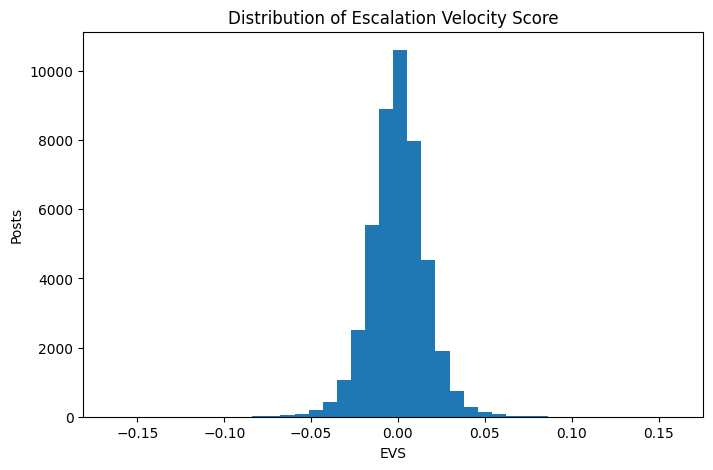

In [39]:
# hist plot for distribution of Escalation Velocity Score

plt.figure(figsize=(8,5))

plt.hist(
    df["evs"],
    bins=40
)

plt.title("Distribution of Escalation Velocity Score")

plt.xlabel("EVS")

plt.ylabel("Posts")

plt.show()

In [40]:
# creating trajectory labels

low = df["evs"].quantile(0.33)
high = df["evs"].quantile(0.67)

print(low)
print(high)

-0.005998636444783055
0.006065881438909775


In [41]:
def assign_trajectory(evs):

    if evs <= low:
        return "Recovering"

    elif evs >= high:
        return "Escalating"

    else:
        return "Stable"

df["trajectory"] = df["evs"].apply(assign_trajectory)

In [42]:
print(df["trajectory"].value_counts())

trajectory
Stable        15332
Recovering    14883
Escalating    14883
Name: count, dtype: int64


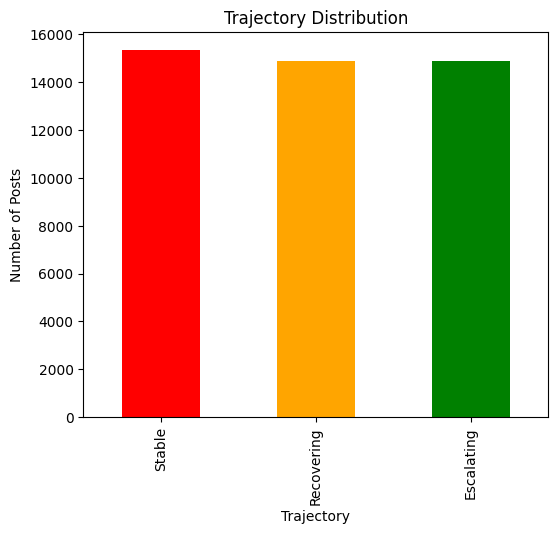

In [43]:
# trajectory distribution


plt.figure(figsize=(6,5))

df["trajectory"].value_counts().plot(
    kind="bar",
    color=["red","orange","green"]
)

plt.title("Trajectory Distribution")
plt.xlabel("Trajectory")
plt.ylabel("Number of Posts")

plt.show()

In [44]:
# creating final dataset for Models

trajectory_df = df[[
    "user_id",
    "clean_text",
    "date",
    "severity_score",
    "sentiment",
    "depression_keyword",
    "suicide_keyword",
    "evs",
    "trajectory"
]].copy()

In [45]:
trajectory_df.head()

,user_id,clean_text,date,severity_score,sentiment,depression_keyword,suicide_keyword,evs,trajectory
0,subject0,little late agree thought saying bad overall s...,2013-09-10 23:16:04,0.199715,0.167275,0.0,0.0,0.000000,Stable
1,subject0,regular monster ruined drinking friend mine sa...,2013-09-15 10:51:21,0.161983,0.467720,0.0,0.0,-0.018866,Recovering
2,subject0,elaborate prostitution,2013-09-15 11:06:58,0.163618,0.499925,0.0,0.0,-0.005744,Stable
3,subject0,free porn site pornhub redtube owned company p...,2013-09-15 12:09:09,0.078450,0.929339,0.0,0.0,-0.024164,Recovering
4,subject0,use site feel exploited ask donate keep free s...,2013-09-15 12:23:11,0.142237,0.771116,0.0,0.0,-0.001741,Stable


## EDA - EXPLORATORY DATA ANALYSIS

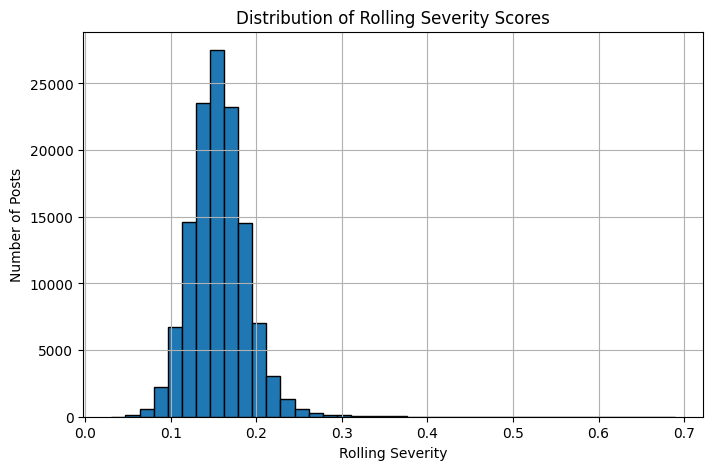

In [ ]:
# rolling severity

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["rolling_severity"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Rolling Severity")
plt.ylabel("Number of Posts")
plt.title("Distribution of Rolling Severity Scores")

plt.grid(True)

plt.show()

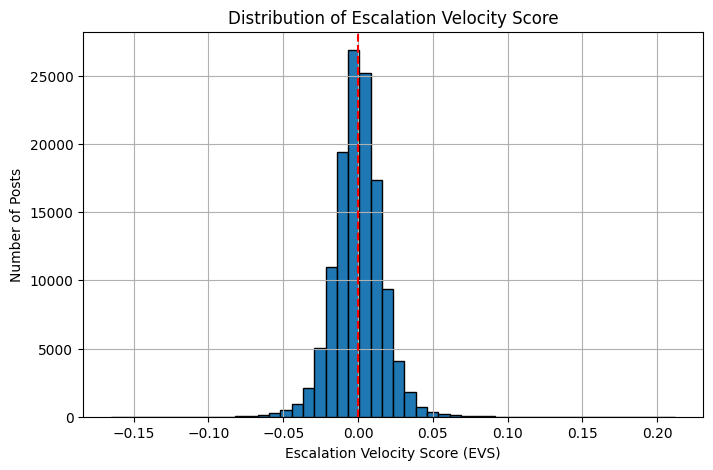

In [ ]:
# EVS distribution

plt.figure(figsize=(8,5))

plt.hist(
    df["evs"],
    bins=50,
    edgecolor="black"
)

plt.axvline(0,color="red",linestyle="--")

plt.xlabel("Escalation Velocity Score (EVS)")
plt.ylabel("Number of Posts")
plt.title("Distribution of Escalation Velocity Score")

plt.grid(True)

plt.show()

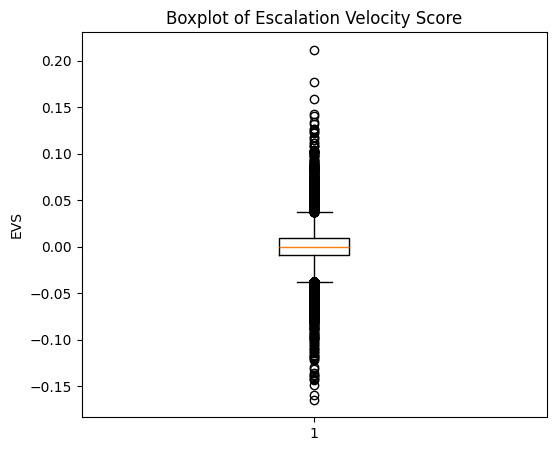

In [ ]:
# evs boxplot

plt.figure(figsize=(6,5))

plt.boxplot(df["evs"])

plt.title("Boxplot of Escalation Velocity Score")

plt.ylabel("EVS")

plt.show()

trajectory
Stable        42751
Recovering    41493
Escalating    41493
Name: count, dtype: int64


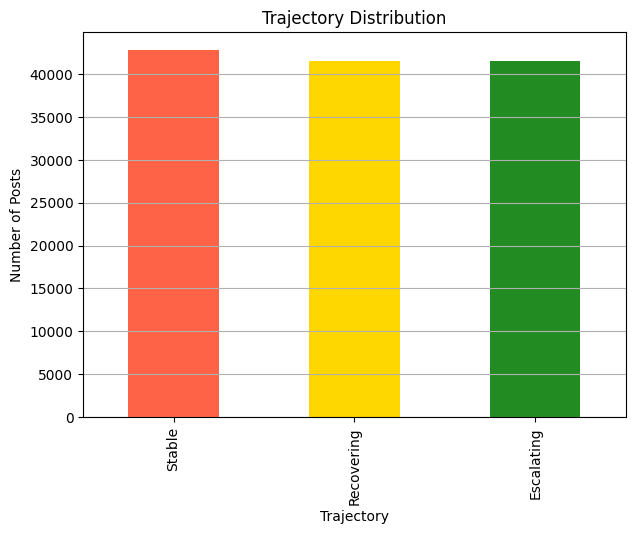

In [ ]:
# trajectory distribution

trajectory_counts = df["trajectory"].value_counts()

print(trajectory_counts)

plt.figure(figsize=(7,5))

trajectory_counts.plot(
    kind="bar",
    color=["tomato","gold","forestgreen"]
)

plt.xlabel("Trajectory")

plt.ylabel("Number of Posts")

plt.title("Trajectory Distribution")

plt.grid(axis="y")

plt.show()

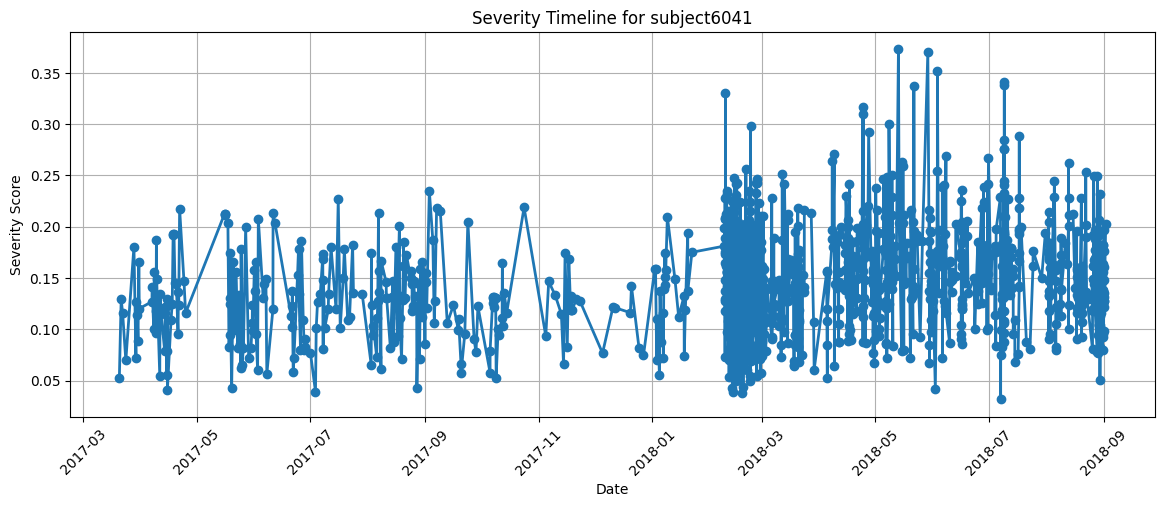

In [ ]:
# timeline of sample user

sample_user = df["user_id"].value_counts().index[0]

user_df = df[df["user_id"] == sample_user]

plt.figure(figsize=(14,5))

plt.plot(
    user_df["date"],
    user_df["severity_score"],
    marker="o",
    linewidth=2
)

plt.title(f"Severity Timeline for {sample_user}")

plt.xlabel("Date")

plt.ylabel("Severity Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

count     340.000000
mean      369.814706
std       373.807569
min         1.000000
25%        54.000000
50%       212.500000
75%       621.250000
max      1342.000000
dtype: float64


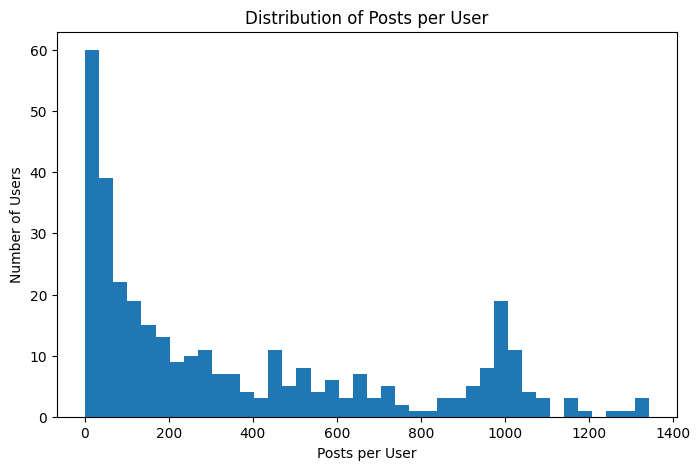

In [ ]:
# posts per user

posts_per_user = df.groupby("user_id").size()

print(posts_per_user.describe())

plt.figure(figsize=(8,5))

plt.hist(
    posts_per_user,
    bins=40
)

plt.xlabel("Posts per User")

plt.ylabel("Number of Users")

plt.title("Distribution of Posts per User")

plt.show()

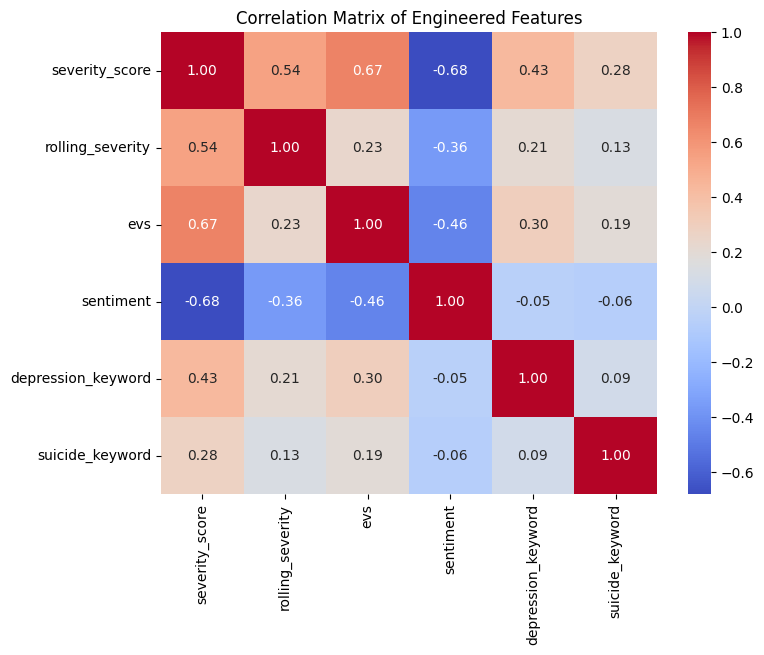

In [ ]:
# correlation between features

import seaborn as sns

features = [

    "severity_score",

    "rolling_severity",

    "evs",

    "sentiment",

    "depression_keyword",

    "suicide_keyword"

]

plt.figure(figsize=(8,6))

sns.heatmap(

    df[features].corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix of Engineered Features")

plt.show()

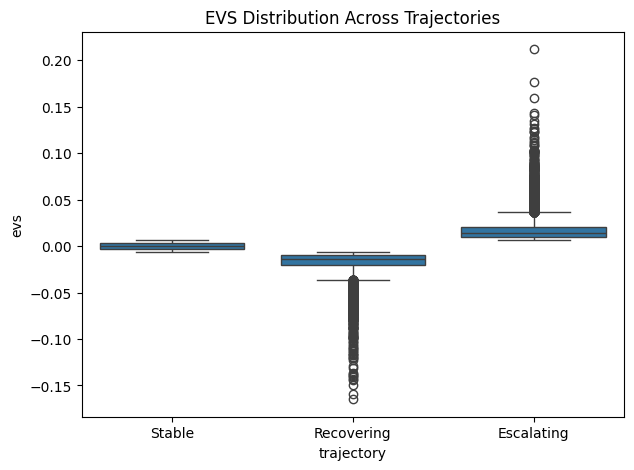

In [ ]:
# evs by trajectory

plt.figure(figsize=(7,5))

sns.boxplot(

    x="trajectory",

    y="evs",

    data=df

)

plt.title("EVS Distribution Across Trajectories")

plt.show()

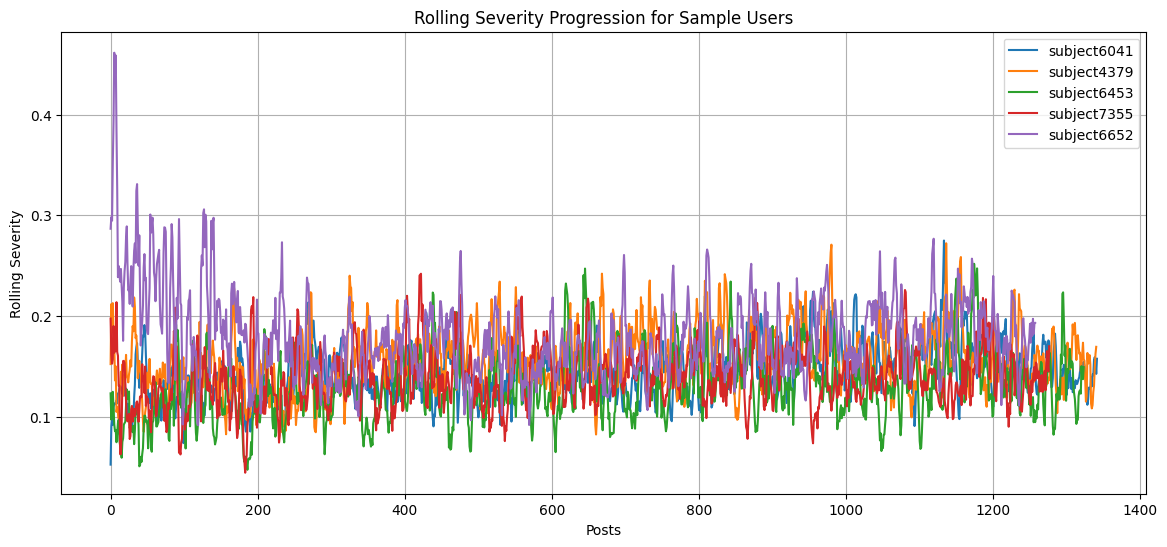

In [ ]:
# rolling severity overtime (multiple users)

top_users = df["user_id"].value_counts().head(5).index

plt.figure(figsize=(14,6))

for user in top_users:

    user_df = df[df["user_id"] == user]

    plt.plot(
        user_df["rolling_severity"].values,
        label=user
    )

plt.legend()

plt.xlabel("Posts")

plt.ylabel("Rolling Severity")

plt.title("Rolling Severity Progression for Sample Users")

plt.grid(True)

plt.show()

## BASELINE 1 - LOGISTIC REGRESSION + TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import LabelEncoder

In [ ]:
# preparing dataset

X_text = trajectory_df["clean_text"]

encoder = LabelEncoder()

y = encoder.fit_transform(
    trajectory_df["trajectory"]
)

In [ ]:
# TF-IDF

vectorizer = TfidfVectorizer(

    max_features=10000,

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95,

    sublinear_tf=True

)

X = vectorizer.fit_transform(X_text)

In [ ]:
# train/test/split

X_train_lr,\
X_test_lr,\
y_train_lr,\
y_test_lr = train_test_split(

    X,

    y,

    stratify=y,

    test_size=0.20,

    random_state=42

)

In [ ]:
lr_model = LogisticRegression(

    max_iter=3000,

    class_weight="balanced",

    random_state=42

)

lr_model.fit(

    X_train_lr,

    y_train_lr


)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)

In [ ]:
# PRED

lr_pred = lr_model.predict(X_test_lr)

In [ ]:
#EVAL

lr_accuracy = accuracy_score(

    y_test_lr,

    lr_pred

)

print("Accuracy :", lr_accuracy)

print()

print(

classification_report(

    y_test_lr,

    lr_pred,

    target_names=encoder.classes_

)

)

Accuracy : 0.47387466200095435

              precision    recall  f1-score   support

  Escalating       0.53      0.53      0.53      8299
  Recovering       0.49      0.53      0.51      8299
      Stable       0.40      0.37      0.38      8550

    accuracy                           0.47     25148
   macro avg       0.47      0.47      0.47     25148
weighted avg       0.47      0.47      0.47     25148



In [ ]:
lr_accuracy = print("Accuracy :", lr_accuracy)

Accuracy : 0.47387466200095435


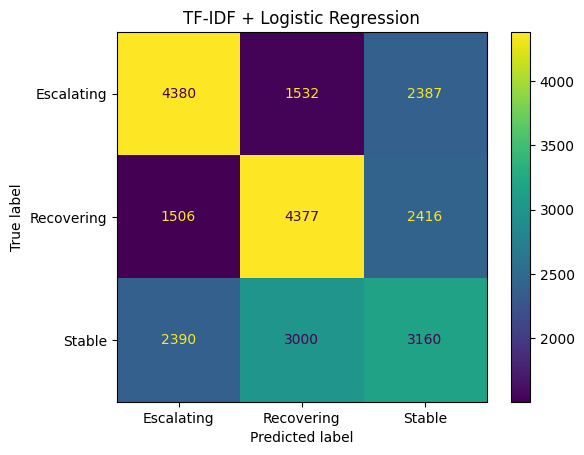

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(

    y_test_lr,

    lr_pred

)

ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=encoder.classes_

).plot()

plt.title("TF-IDF + Logistic Regression")

plt.show()

In [ ]:
# shap

import shap

In [ ]:
# feature names

feature_names = list(vectorizer.get_feature_names_out())

print("Vocabulary Size:", len(feature_names))

Vocabulary Size: 10000


In [ ]:
#create explainer

explainer = shap.LinearExplainer(
    lr_model,
    X_train_lr
)

In [ ]:
# computing shap on approx 1000 samples

sample_size = min(1000, X_test_lr.shape[0])

X_sample = X_test_lr[:sample_size]

shap_values = explainer(X_sample)

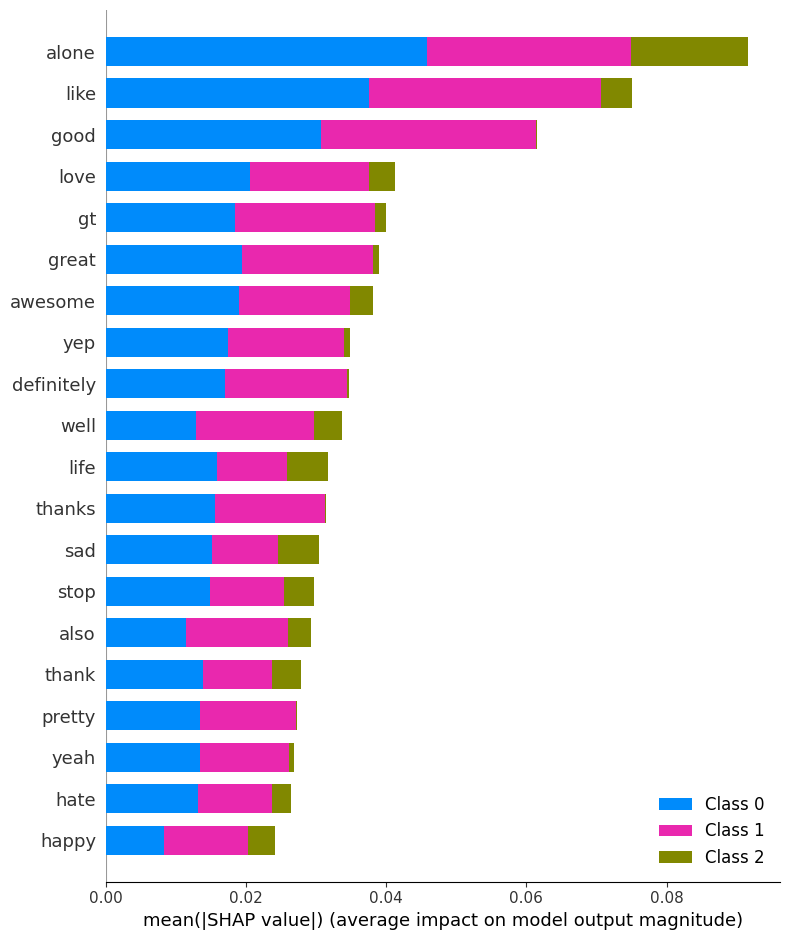

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=vectorizer.get_feature_names_out()
)

## BASELINE 2 MENTAL BERT

In [ ]:
#Import libraries

import torch

from transformers import (

AutoTokenizer,

AutoModelForSequenceClassification,

Trainer,

TrainingArguments

)

from datasets import Dataset

In [ ]:
# Sample 20% while preserving trajectory distribution

bert_df, _ = train_test_split(
    trajectory_df,
    train_size=0.20,
    stratify=trajectory_df["trajectory"],
    random_state=42
)

print(bert_df["trajectory"].value_counts())

trajectory
Stable        8550
Recovering    8299
Escalating    8298
Name: count, dtype: int64


In [ ]:
train_df, test_df = train_test_split(
    bert_df,
    test_size=0.20,
    stratify=bert_df["trajectory"],
    random_state=42
)

In [ ]:
# encode
encoder = LabelEncoder()

bert_df["label"] = encoder.fit_transform(

    bert_df["trajectory"]

)

In [ ]:
#train/test/split

train_df,\
test_df = train_test_split(

    bert_df,

    stratify=bert_df["label"],

    random_state=42,

    test_size=0.20

)

In [ ]:
# model

model_name = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

In [ ]:
#tokenize

def tokenize(batch):

    return tokenizer(

        batch["clean_text"],

        padding="max_length",

        truncation=True,

        max_length=128

    )

In [ ]:
# dataset

train_dataset = Dataset.from_pandas(
    train_df
)

test_dataset = Dataset.from_pandas(
    test_df
)

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/20117 [00:00<?, ? examples/s]

Map:   0%|          | 0/5030 [00:00<?, ? examples/s]

In [ ]:
# initializing the mental bert

model = AutoModelForSequenceClassification.from_pretrained(

    model_name,

    num_labels=3

)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

In [ ]:
#training args


training_args = TrainingArguments(

    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=100

)

In [ ]:
#trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset

)

In [ ]:
# train

trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch,Training Loss,Validation Loss
1,1.013107,0.999985
2,0.879629,1.060411
3,0.654823,1.275228


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3774, training_loss=0.8644693179552556, metrics={'train_runtime': 1458.3019, 'train_samples_per_second': 41.384, 'train_steps_per_second': 2.588, 'total_flos': 3969789468325632.0, 'train_loss': 0.8644693179552556, 'epoch': 3.0})

In [ ]:
# Evaluating

predictions = trainer.predict(
    test_dataset
)

pred = np.argmax(

    predictions.predictions,

    axis=1

)

y_true = test_df["label"]

print(

classification_report(

    y_true,

    pred,

    target_names=encoder.classes_

)

)

              precision    recall  f1-score   support

  Escalating       0.55      0.51      0.53      1660
  Recovering       0.53      0.45      0.49      1660
      Stable       0.39      0.47      0.43      1710

    accuracy                           0.48      5030
   macro avg       0.49      0.48      0.48      5030
weighted avg       0.49      0.48      0.48      5030



In [ ]:
print("accuracy:", accuracy_score(y_true, pred))

accuracy: 0.47773359840954277


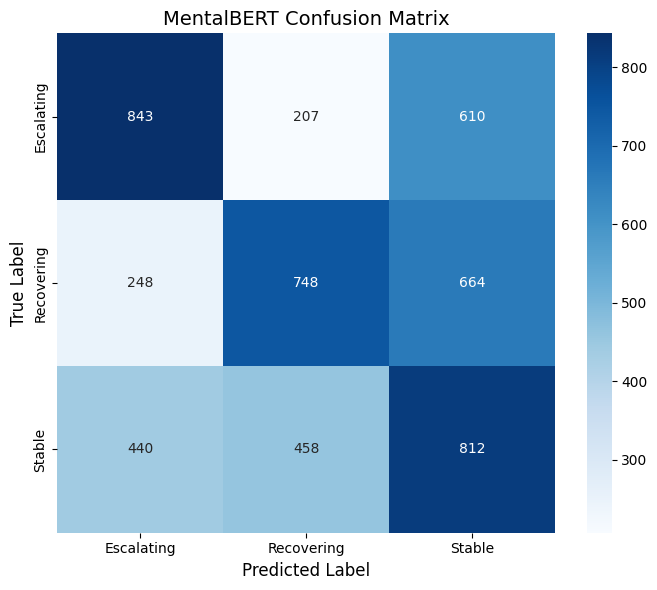

In [ ]:
#confusion matrix

cm = confusion_matrix(y_true, pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("MentalBERT Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

LSTM

In [91]:
# Import libraries

import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

In [78]:
# selecting features

features = [
    "severity_score",
    "sentiment",
    "depression_keyword",
    "suicide_keyword",
    "evs"
]

print("Features used:")
print(features)

Features used:
['severity_score', 'sentiment', 'depression_keyword', 'suicide_keyword', 'evs']


In [79]:
# encoding labels
encoder = LabelEncoder()

trajectory_df["trajectory_label"] = encoder.fit_transform(
    trajectory_df["trajectory"]
)

print("Encoded classes:")
print(encoder.classes_)

Encoded classes:
['Escalating' 'Recovering' 'Stable']


In [80]:
# split the users
unique_users = trajectory_df["user_id"].unique()

# 80% development, 20% test
train_val_users, test_users = train_test_split(
    unique_users,
    test_size=0.20,
    random_state=42
)

# Split development users into train and validation
train_users, val_users = train_test_split(
    train_val_users,
    test_size=0.20,
    random_state=42
)

print("Training users:", len(train_users))
print("Validation users:", len(val_users))
print("Test users:", len(test_users))

Training users: 77
Validation users: 20
Test users: 25


In [81]:
# creatng three dataframes

train_df = trajectory_df[
    trajectory_df["user_id"].isin(train_users)
].copy()

val_df = trajectory_df[
    trajectory_df["user_id"].isin(val_users)
].copy()

test_df = trajectory_df[
    trajectory_df["user_id"].isin(test_users)
].copy()

In [82]:
# scaling only TRAIN
scaler = MinMaxScaler()

# Fit ONLY on training data
train_df[features] = scaler.fit_transform(
    train_df[features]
)

# Apply the same scaler to validation and test
val_df[features] = scaler.transform(
    val_df[features]
)

test_df[features] = scaler.transform(
    test_df[features]
)

In [83]:
# creating sequences separately

sequence_length = 10


def create_sequences(
    dataframe,
    features,
    sequence_length=10
):

    X = []
    y = []

    for user in dataframe["user_id"].unique():

        user_df = dataframe[
            dataframe["user_id"] == user
        ].sort_values("date")

        values = user_df[features].values

        labels = user_df["trajectory_label"].values

        if len(values) <= sequence_length:
            continue

        for i in range(
            len(values) - sequence_length
        ):

            X.append(
                values[
                    i:i + sequence_length
                ]
            )

            y.append(
                labels[
                    i + sequence_length
                ]
            )

    return np.array(X), np.array(y)


In [84]:
X_train, y_train = create_sequences(
    train_df,
    features,
    sequence_length
)

X_val, y_val = create_sequences(
    val_df,
    features,
    sequence_length
)

X_test, y_test = create_sequences(
    test_df,
    features,
    sequence_length
)

In [85]:
# resulting shapes

print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Training shape: (23975, 10, 5) (23975,)
Validation shape: (7685, 10, 5) (7685,)
Test shape: (12238, 10, 5) (12238,)


In [86]:
# one hot encoding
y_train_cat = to_categorical(
    y_train,
    num_classes=3
)

y_val_cat = to_categorical(
    y_val,
    num_classes=3
)

y_test_cat = to_categorical(
    y_test,
    num_classes=3
)

In [92]:
# evs + lstm
model = Sequential([

    Input(
        shape=(
            sequence_length,
            len(features)
        )
    ),

    LSTM(64),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        3,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,099 (78.51 KB)

 Trainable params: 20,099 (78.51 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# compile

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
# training callbacks

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [96]:
# training evs + lstm

history = model.fit(
    X_train,
    y_train_cat,

    validation_data=(
        X_val,
        y_val_cat
    ),

    epochs=30,

    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3683 - loss: 1.0916 - val_accuracy: 0.4177 - val_loss: 1.0765 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4194 - loss: 1.0630 - val_accuracy: 0.4488 - val_loss: 1.0418 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4540 - loss: 1.0366 - val_accuracy: 0.4703 - val_loss: 1.0172 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4813 - loss: 1.0037 - val_accuracy: 0.5284 - val_loss: 0.9413 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5412 - loss: 0.9310 - val_accuracy: 0.5623 - val_loss: 0.8984 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5528 - loss: 0.9058 - val_accuracy: 0.5561 - val_loss: 0.8967 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5660 - loss: 0.8886

In [97]:
# final test evaluation

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print(
    "Test Accuracy:",
    test_accuracy
)

383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5771 - loss: 0.8559
Test Accuracy: 0.5770550966262817


In [99]:
# predictions

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [100]:
# classification report

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

Accuracy: 0.5770550743585553

              precision    recall  f1-score   support

  Escalating       0.67      0.57      0.62      4036
  Recovering       0.63      0.70      0.67      4018
      Stable       0.45      0.46      0.45      4184

    accuracy                           0.58     12238
   macro avg       0.58      0.58      0.58     12238
weighted avg       0.58      0.58      0.58     12238



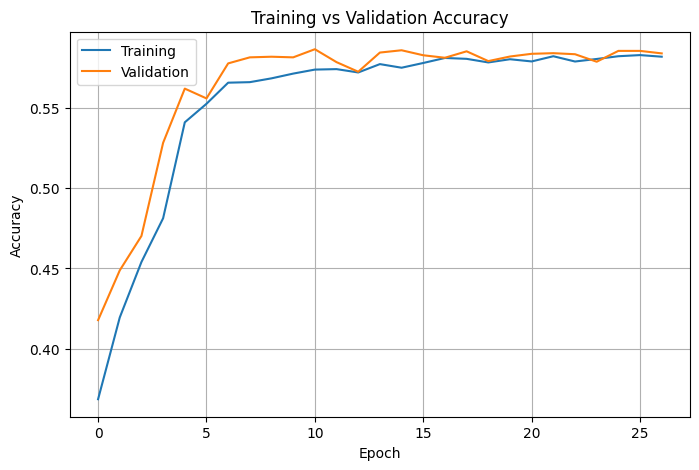

In [101]:
# accuracy plot

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

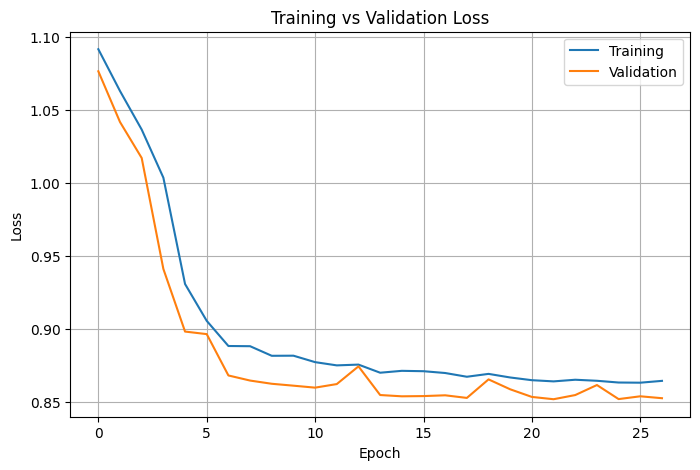

In [102]:
#loss plot

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

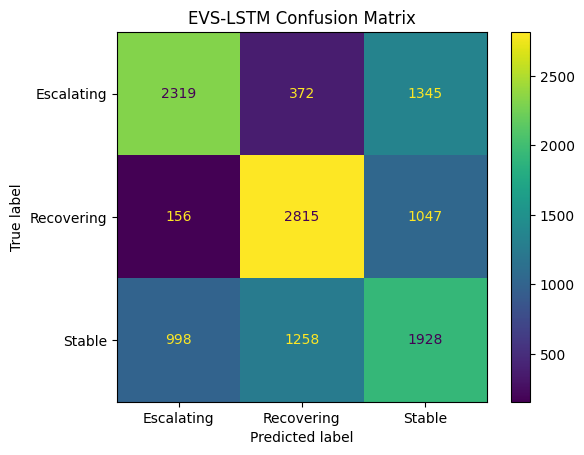

In [103]:
# confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("EVS-LSTM Confusion Matrix")

plt.show()

In [105]:
import shap

In [109]:
sample_size = min(1000, X_test.shape[0])

X_sample = X_test[:sample_size]

print("SHAP sample shape:", X_sample.shape)

SHAP sample shape: (1000, 10, 5)


In [110]:
background_size = min(100, X_train.shape[0])

background = X_train[:background_size]

explainer = shap.GradientExplainer(
    model,
    background
)

print("SHAP explainer created.")

SHAP explainer created.


In [111]:
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated.")

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_20
Received: inputs=['Tensor(shape=(1000, 10, 5))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_20
Received: inputs=['Tensor(shape=(50, 10, 5))']
  warnings.warn(msg)


SHAP values calculated.


In [112]:
print("Type:", type(shap_values))
print("Number of outputs:", len(shap_values) if isinstance(shap_values, list) else "Not a list")

if isinstance(shap_values, list):
    for i, sv in enumerate(shap_values):
        print(f"Class {i} shape:", np.array(sv).shape)
else:
    print("SHAP array shape:", np.array(shap_values).shape)

Type: <class 'numpy.ndarray'>
Number of outputs: Not a list
SHAP array shape: (1000, 10, 5, 3)


In [113]:
# SHAP output:
# (samples, time_steps, features, classes)
print("Original SHAP shape:", shap_values.shape)

# Take absolute SHAP values across the 3 output classes
# This gives global feature importance across all classes.
sv_all = np.mean(
    np.abs(shap_values),
    axis=-1
)

print("After class aggregation:", sv_all.shape)

# Average SHAP values across the 10 time steps
sv_all = sv_all.mean(axis=1)

print("After time aggregation:", sv_all.shape)

Original SHAP shape: (1000, 10, 5, 3)
After class aggregation: (1000, 10, 5)
After time aggregation: (1000, 5)


In [114]:
# plot
X_plot = X_sample.mean(axis=1)

print("X_plot shape:", X_plot.shape)

X_plot shape: (1000, 5)


/tmp/ipykernel_3159/622884056.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


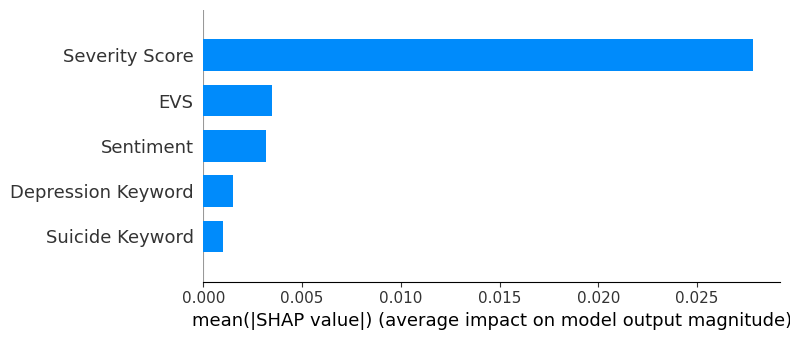

In [115]:
# global plot

feature_names = [
    "Severity Score",
    "Sentiment",
    "Depression Keyword",
    "Suicide Keyword",
    "EVS"
]

shap.summary_plot(
    sv_all,
    X_plot,
    feature_names=feature_names,
    plot_type="bar"
)